In [1]:
# Import libraries

# Data processing and manipulation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from collections import defaultdict
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

from scipy.stats import ks_2samp

from typing import Iterable, Any, Tuple, Dict


# Machine learning models
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, log_loss, average_precision_score, balanced_accuracy_score, accuracy_score
from pathlib import Path


# Custom models
import importlib
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '../src')))

import preprocess_data as ppd
import GAMinferenceModels_V2 as gam_models
import scenario_generation as sg


In [2]:
# failure_data_file = "../DATA/hourly/by_technology/hourly_failure_deltaTime_dataset_Gas_Turbine_Jet_Engine_(Simple_Cycle_Operation).csv"
failure_data_file = "../DATA/hourly/by_technology/hourly_failure_deltaTime_dataset_fullH_Gas_Turbine_Jet_Engine_(Simple_Cycle_Operation).csv"
# failure_data_file = "../DATA/hourly/by_technology/hourly_failure_deltaTime_dataset_2_Gas_Turbine_Jet_Engine_(Simple_Cycle_Operation).csv"


df = pd.read_csv(failure_data_file, usecols=['Datetime_UTC', 'Geographical State', 'Initial_gen_state', 'Final_gen_state', 'Data_weight', 'hours_in_state'], parse_dates=['Datetime_UTC'])
df.rename(columns={'Geographical State': 'State'}, inplace=True)
df['Initial_gen_state'] = df['Initial_gen_state'].replace({'U':'O'})
df['Final_gen_state'] = df['Final_gen_state'].replace({'U':'O'})

In [3]:
test_start_date = '2022-01-01 00:00:00'
test_end_date = '2023-12-31 23:59:59'

mask_test = (df['Datetime_UTC'] >= test_start_date) & (df['Datetime_UTC'] <= test_end_date)

train_df = df[~mask_test].copy()
test_df = df[mask_test].copy()

In [4]:
dwell_times_train = {}

for state in ['A', 'D', 'O']:
    state_df = train_df[(train_df['Initial_gen_state'] == state)&(train_df['Final_gen_state'] != state)]
    v = state_df['hours_in_state'].values
    w = state_df['Data_weight'].values
    dwell_times_train[state] = v.repeat(w.astype(int))

dwell_times_test = {}
for state in ['A', 'D', 'O']:
    state_df = test_df[(test_df['Initial_gen_state'] == state)&(test_df['Final_gen_state'] != state)]
    v = state_df['hours_in_state'].values
    w = state_df['Data_weight'].values
    dwell_times_test[state] = v.repeat(w.astype(int))

In [5]:
dwell_times_generated = {'hist':{}, 'SMC':{}}

dwell_folder = '/Users/malo/MIT Dropbox/Malo Lahogue/Research/Generator-outage-probability/Results/Dwell_times/'


for state in ['A', 'D', 'O']:

    df = pd.read_csv(f"{dwell_folder}/historical_dwell_times_{state}.csv")
    dwell_times_generated['hist'][state] = df['Dwell_time'].values

    df = pd.read_csv(f"{dwell_folder}/generated_dwell_times_Semi-Markov_{state}.csv")
    dwell_times_generated['SMC'][state] = df['Dwell_time'].values
    

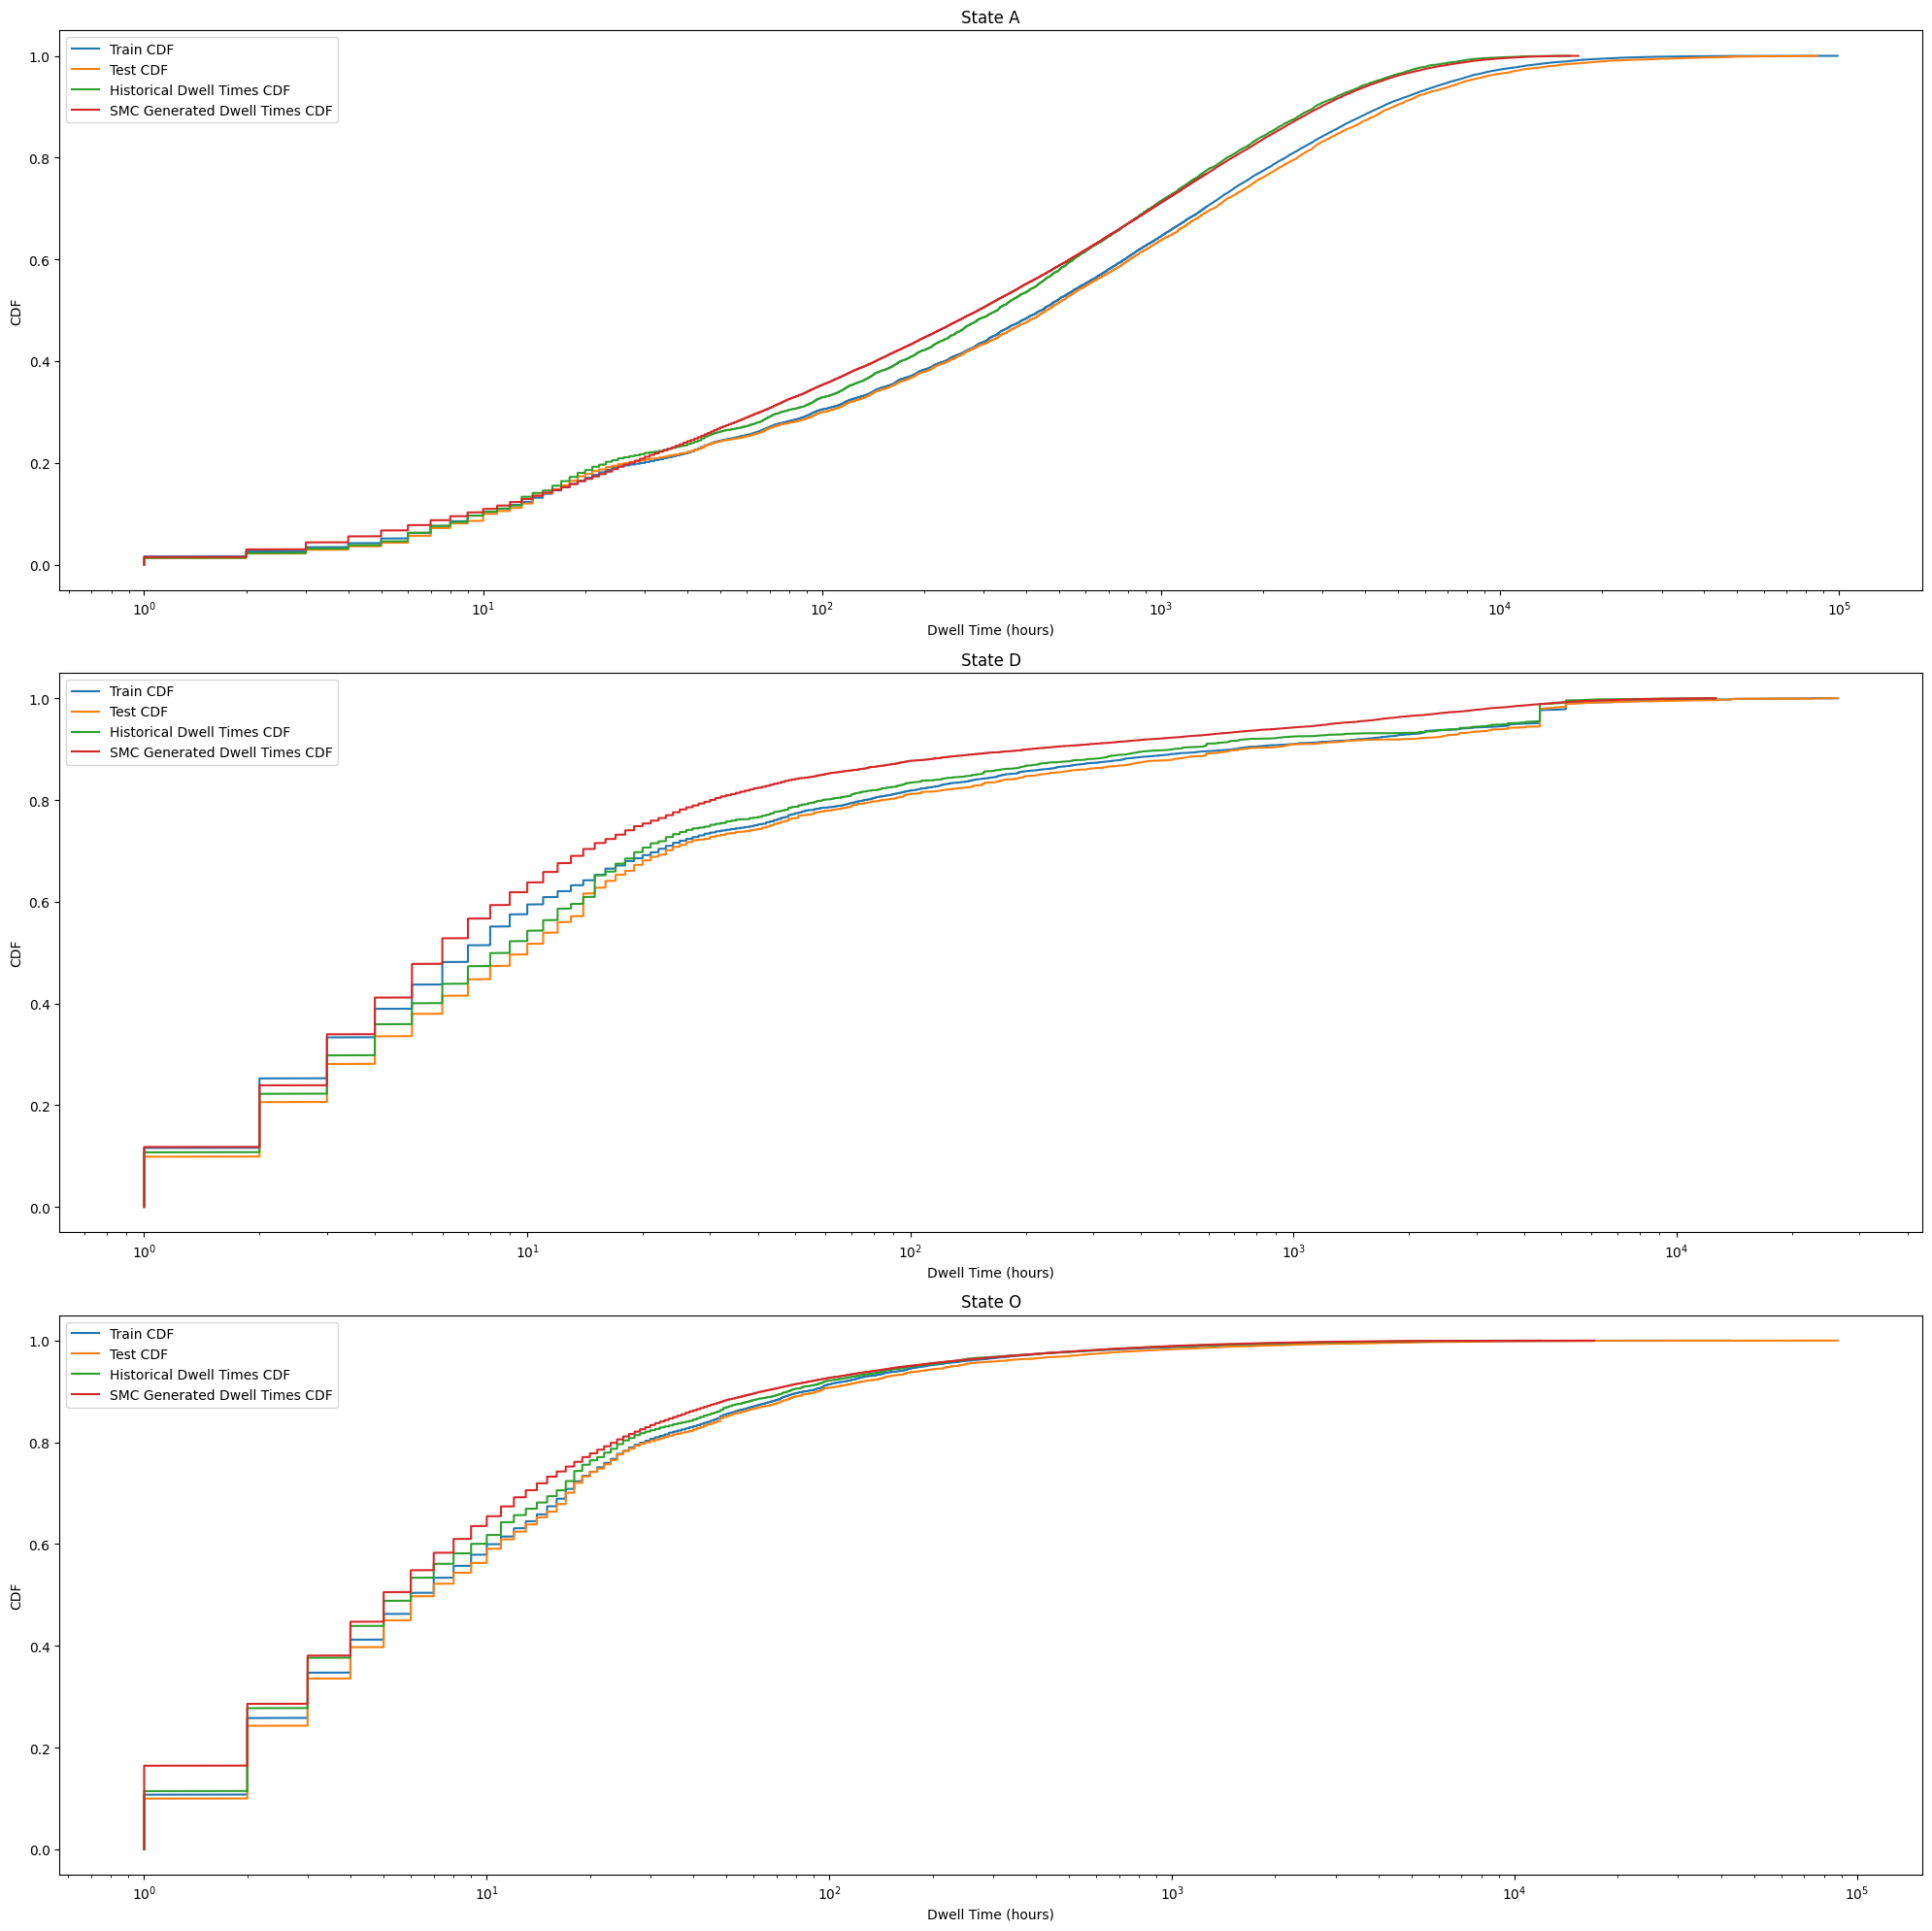

In [7]:
fig, axs = plt.subplots(3,1, figsize=(20, 20))

for i, state in enumerate(['A', 'D', 'O']):
    ax = axs[i]

    x_train = np.sort(dwell_times_train[state])
    cdf_train = np.arange(1, len(x_train)+1) / len(x_train)

    x_test = np.sort(dwell_times_test[state])
    cdf_test = np.arange(1, len(x_test)+1) / len(x_test)


    x_hist = np.sort(dwell_times_generated['hist'][state])
    cdf_hist = np.arange(1, len(x_hist)+1) / len(x_hist)

    x_SMC = np.sort(dwell_times_generated['SMC'][state])
    cdf_SMC = np.arange(1, len(x_SMC)+1) / len(x_SMC)

    ax.plot(x_train, cdf_train, label='Train CDF')
    ax.plot(x_test, cdf_test, label='Test CDF')
    ax.plot(x_hist, cdf_hist, label='Historical Dwell Times CDF')
    ax.plot(x_SMC, cdf_SMC, label='SMC Generated Dwell Times CDF')

    ax.set_title(f'State {state}')
    ax.set_xlabel('Dwell Time (hours)')
    ax.set_ylabel('CDF')
    # ax.set_xlim(4000, 6000)
    ax.set_xscale('log')
    ax.legend()

plt.tight_layout()